In [1]:
import numpy as np
import matplotlib.pyplot as plt

stc_list = ["In the beginning God created the heavens and the earth.",
        "Now the earth was formless and empty, darkness was over the surface of the deep, and the Spirit of God was hovering over the waters.",
        "And God said, “Let there be light,” and there was light.",
        "God saw that the light was good, and he separated the light from the darkness.",
        "God called the light “day,” and the darkness he called “night.” And there was evening, and there was morning—the first day.",
        "And God said, 'Let there be a vault between the waters to separate water from water.'",
        "So God made the vault and separated the water under the vault from the water above it. And it was so.",
        "God called the vault 'sky.' And there was evening, and there was morning—the second day."]
cleaned_stc_list = []
for stc in stc_list:
    cleaned = stc.lower().replace('“', '').replace('”', '').replace('’', '').replace('.', '').replace(',', '').replace('-', ' ').replace("'", "")
    cleaned_stc_list.append(cleaned)

# Tạo từ điển (vocabulary) từ danh sách câu đã làm sạch
vocab = sorted({word for s in cleaned_stc_list for word in s.split()})

def to_vector(stc_cleaned):
    v = np.zeros(len(vocab))
    for word in stc_cleaned.split():
        if word in vocab:
            v[vocab.index(word)] += 1
    return v

X = np.array([to_vector(s) for s in cleaned_stc_list])
print("Shape của ma trận X:", X.shape)

Shape của ma trận X: (8, 50)


Bài 1.1: X(8,50) có nghĩa là: 
8 hàng là 8 câu trong list câu ban đầu (mỗi hàng ứng với một câu)
50 cột là 50 từ duy nhất xuất hiện trong toàn bộ văn bản
X[i,j] biểu thị số lần xuất hiện từ index j trong câu i.


In [2]:
X_mean = X.mean(axis=0)
X_center = X - X_mean
print("Shape matrix gốc:", X.shape)
print("Shape vector norm :", X_mean.shape)
print("Shape matrix sau khi broadcasting:", X_center.shape)

Shape matrix gốc: (8, 50)
Shape vector norm : (50,)
Shape matrix sau khi broadcasting: (8, 50)


Bài 1.2:
X.mean(axis=0) để tính giá trị trung bình theo từng cột, return vector 1 chiều có size n (với n là số từ vựng)
X - X_mean là áp dụng quy tắc Broadcasting: tự mở rộng vector X_mean để khớp shape ma trận X

In [3]:
def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X
    Xn = X / np.linalg.norm(X,axis=1,keepdims=True)
    Yn = Y / np.linalg.norm(Y,axis=1,keepdims=True)
    return Xn @ Yn.T
simi_matrix = cosine_similarity(X)
print(simi_matrix.shape)

(8, 8)


Bài 1.3

In [4]:
def search(query, top_k=3):
    q_vector = to_vector(query).reshape(1, -1)
    scores = cosine_similarity(q_vector, X).flatten()
    top_indices = np.argsort(scores)[::-1][:top_k]
    print(f"Kết quả tìm kiếm cho query: '{query}'\n")
    for idx in top_indices:
        print(f"Cosine Similarity: {scores[idx]:.4f} | Câu gốc: {stc_list[idx]}")
#test
search("God created the light", top_k=3)
matrix_copy = simi_matrix.copy()
np.fill_diagonal(matrix_copy, 0)
max_idx = np.unravel_index(np.argmax(matrix_copy), matrix_copy.shape)
np.fill_diagonal(matrix_copy, np.inf)
min_idx = np.unravel_index(np.argmin(matrix_copy), matrix_copy.shape)
print(f"Cặp câu giống nhau nhất là câu {max_idx[0]} và câu {max_idx[1]} với độ tương đồng: {simi_matrix[max_idx]:.4f}")
print(f"Cặp câu khác nhau nhất là câu {min_idx[0]} và câu {min_idx[1]} với độ tương đồng: {simi_matrix[min_idx]:.4f}")

Kết quả tìm kiếm cho query: 'God created the light'

Cosine Similarity: 0.6019 | Câu gốc: God saw that the light was good, and he separated the light from the darkness.
Cosine Similarity: 0.5774 | Câu gốc: In the beginning God created the heavens and the earth.
Cosine Similarity: 0.3824 | Câu gốc: Now the earth was formless and empty, darkness was over the surface of the deep, and the Spirit of God was hovering over the waters.
Cặp câu giống nhau nhất là câu 4 và câu 7 với độ tương đồng: 0.8251
Cặp câu khác nhau nhất là câu 0 và câu 2 với độ tương đồng: 0.1819


Bài 1.4 và 1.5

Ở đây câu 4 và câu 7 có độ tương đồng cosine cao nhất là vì câu 4 và 7 có nhiều từ trùng lặp nhau ("God", "the", "and", "separated", "from", "was", ...), tần suất xuất hiện từ lặp khá nhiều và cấu trúc của 2 câu mang tính song hành. Tương tự, ta có câu 0 và câu 2 có độ tương đồng cosine ít nhất vì số lần có từ trùng nhau ít ("God", "and"). Mặc dù kết quả đúng với trực giác nhưng có thể thấy rằng mô hình Bag-of-words có khuyết điểm là chỉ nhìn vào bề nổi của từ vựng chứ không nhìn vào được ngữ nghĩa sâu xa bên dưới.

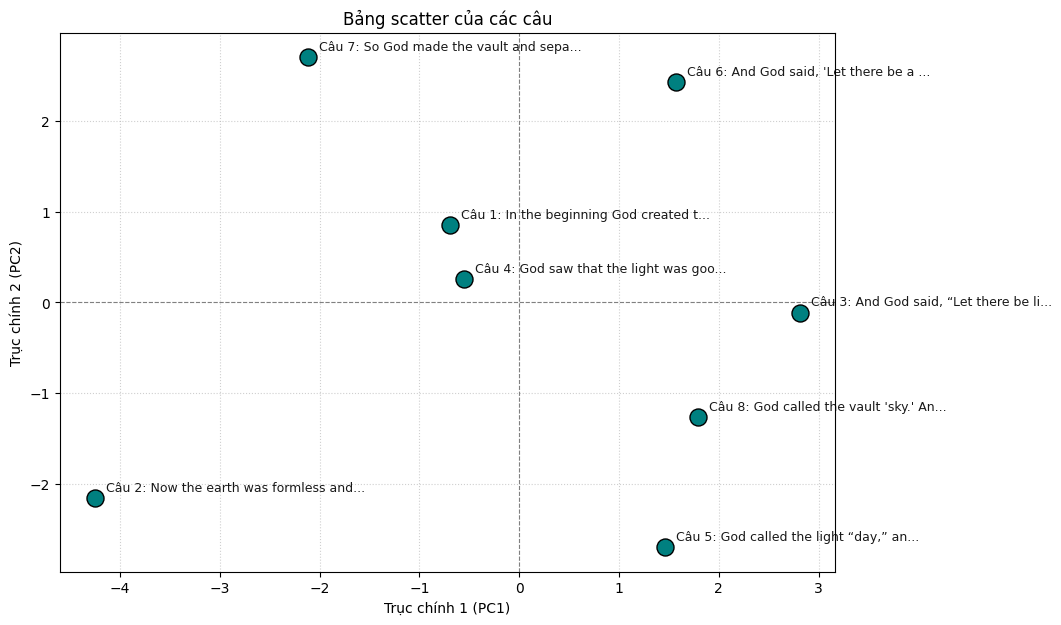

In [5]:
Xc = X - X.mean(axis=0)
U,S,Vt = np.linalg.svd ( Xc , full_matrices = False )
coords = U[:,:2] * S[:2]

plt.figure(figsize=(10, 7))
plt.scatter(coords[:, 0], coords[:, 1], color='teal', edgecolors='black', s=150, zorder=3, label="Câu văn")
for i, stc in enumerate(stc_list):
    short_label = f"Câu {i+1}: {stc[:30]}..." if len(stc) > 30 else f"Câu {i+1}: {stc}"
    plt.annotate(short_label, (coords[i, 0], coords[i, 1]),
                 textcoords="offset points", xytext=(8, 5), fontsize=9, alpha=0.9)

plt.title("Bảng scatter của các câu")
plt.xlabel("Trục chính 1 (PC1)")
plt.ylabel("Trục chính 2 (PC2)")
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Bài 2:

Nhận xét đồ thị: Trên không gian đồ thị 2D, các câu cùng chủ đề hoặc chia sẻ nhiều từ khóa chung (ví dụ: nhóm câu về ánh sáng/ngày đêm, nhóm câu về vòm trời/nước) có xu hướng nằm tụ lại gần nhau. Kết quả này hoàn toàn khớp với trực giác ngữ nghĩa của con người.

Liên hệ với Eigen, PCA và "Trục chính": Phép phân rã SVD trên ma trận dữ liệu đã dịch tâm tương đương với thuật toán PCA. Các dòng của ma trận Vt chính là các Vector riêng (Eigenvectors), đại diện cho các "Trục chính" của dữ liệu. Trục chính 1 (PC1) chứa độ phân tán lớn nhất, trục chính 2 (PC2) chứa độ phân tán lớn thứ nhì. Các trị kỳ dị S chính là căn bậc hai của các Trị riêng (Eigenvalues).

Lý do chỉ giữ lại 2 trục đầu: Ma trận có 8 câu nên không gian gốc có tối đa 8 chiều độc lập (tương ứng từ PC1 đến PC8). Tuy nhiên, để trực quan hóa trên đồ thị phẳng, chúng ta thực hiện một phép chiếu tuyến tính để "ép" không gian 8 chiều này xuống mặt phẳng 2 chiều tối ưu nhất (căng bởi PC1 và PC2). Mặt phẳng này giúp bảo toàn khoảng cách và cấu trúc hình học giữa các câu tốt nhất, đó là lý do vì sao sau khi giảm chiều, các câu cùng chủ đề vẫn đứng gần nhau.

In [6]:
def cls_1NN(train_matrix, train_labels, test_query):
    query_cleaned = test_query.lower().replace('“', '').replace('”', '').replace('’', '').replace('.', '').replace(',', '')
    q_vector = to_vector(query_cleaned).reshape(1, -1)
    scores = cosine_similarity(q_vector, train_matrix).flatten()
    nearest_idx = np.argmax(scores)
    return nearest_idx, scores[nearest_idx]

train_labels = [f"Topic_Sentence_{i+1}" for i in range(len(stc_list))]
#test
test_sentence = "The creator divided the light from darkness."
matched_index, similarity_score = cls_1NN(X, train_labels, test_sentence)

print("--- KẾT QUẢ PHÂN LOẠI 1-NN  ---")
print(f"Câu kiểm tra (Test): '{test_sentence}'")
print(f"Câu gần nhất tìm được: '{stc_list[matched_index]}'")
print(f"Độ tương đồng Cosine: {similarity_score:.4f}")
print(f"Nhãn được gán: {train_labels[matched_index]}")

--- KẾT QUẢ PHÂN LOẠI 1-NN  ---
Câu kiểm tra (Test): 'The creator divided the light from darkness.'
Câu gần nhất tìm được: 'God saw that the light was good, and he separated the light from the darkness.'
Độ tương đồng Cosine: 0.7881
Nhãn được gán: Topic_Sentence_4


Thuật toán 1-NN chạy bằng cách đo độ tương đồng của câu test (cần phân loại) với tất cả mẫu trong tập có sẵn (train_labels), sau đó chọn câu có độ tương đồng cao nhất. Cuối cùng, thuật toán lấy nhãn của câu gần nhất làm nhãn dự đoán cho câu mới.